## P4-Tugas Mandiri

# Business Understanding
# Tujuan: Memprediksi besaran tip ('tip') berdasarkan tagihan dan karakteristik reservasi.
Supervised Learning - Regression

Evaluasi Metrik: MAE, RMSE, R2 Score

In [1]:
# Import Library yang dibutuhkan

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# Data Understanding
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

print("--- 5 Data Teratas ---")
print(df.head())
print("\n--- Info Struktur Dataset ---")
print(df.info())
print("\n--- Pengecekan Missing Value ---")
print(df.isnull().sum())

--- 5 Data Teratas ---
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

--- Info Struktur Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None

--- Pengecekan Missing Value ---
total_bill    0
tip           0
sex           0

dataset ini berukuran 244 baris dan 7 kolom yang mencatat data transaksi restoran secara lengkap tanpa ada data kosong (missing values). Datanya merupakan kombinasi antara 3 kolom numerik (total_bill, tip, size) dan 4 kolom kategorikal (sex, smoker, day, time), sehingga data sudah bersih dan langsung siap masuk ke tahap encoding dan pemodelan.

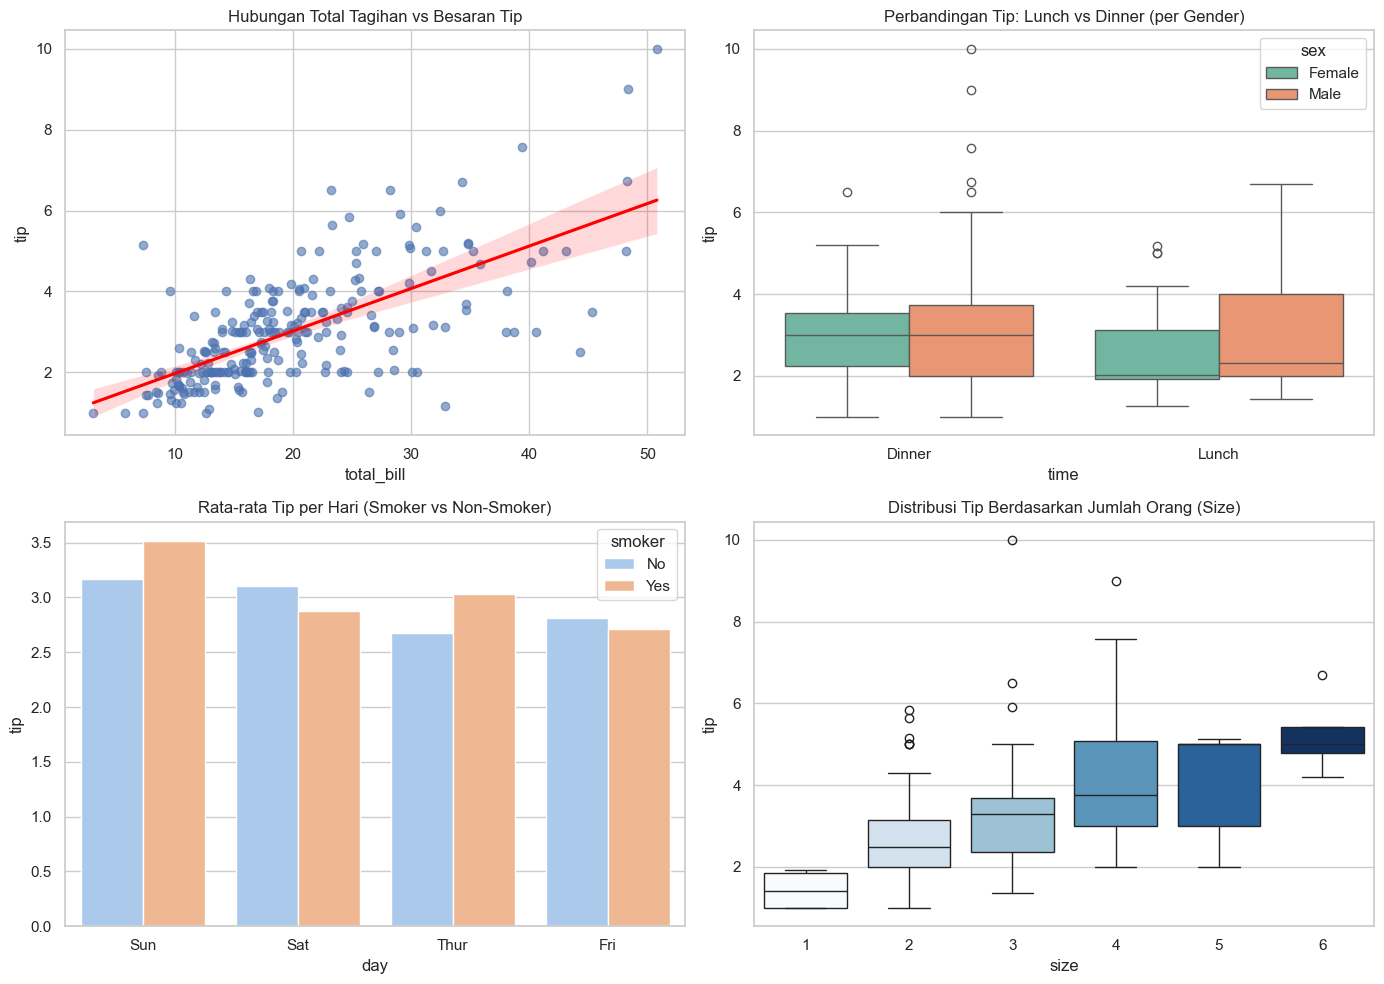

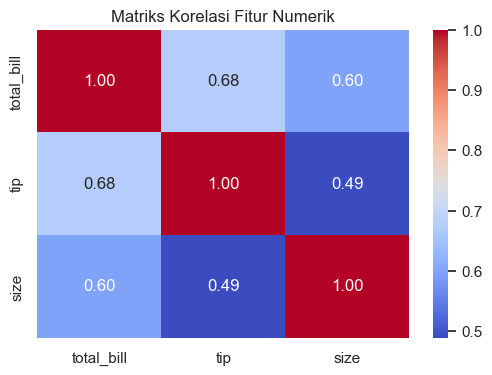

In [8]:
# Korelasi Total Bill vs Tip (Scatter + Regression Line)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.regplot(
    data=df,
    x="total_bill",
    y="tip",
    ax=axes[0, 0],
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
)
axes[0, 0].set_title("Hubungan Total Tagihan vs Besaran Tip", fontsize=12)

# Distribusi Tip per Waktu Makan (Boxplot Lunch vs Dinner)
sns.boxplot(data=df, x="time", y="tip", hue="sex", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Perbandingan Tip: Lunch vs Dinner (per Gender)", fontsize=12)

# Rata-rata Tip Berdasarkan Hari (Barplot)
sns.barplot(
    data=df,
    x="day",
    y="tip",
    hue="smoker",
    ax=axes[1, 0],
    palette="pastel",
    errorbar=None,
)
axes[1, 0].set_title("Rata-rata Tip per Hari (Smoker vs Non-Smoker)", fontsize=12)

# Pengaruh Jumlah Orang (Size) terhadap Tip (Violin / Strip Plot)
sns.boxplot(data=df, x="size", y="tip", hue="size", ax=axes[1, 1], palette="Blues", legend=False)
axes[1, 1].set_title("Distribusi Tip Berdasarkan Jumlah Orang (Size)", fontsize=12)

plt.tight_layout()
plt.show()

# Heatmap Korelasi untuk Fitur Numerik
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[["total_bill", "tip", "size"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Matriks Korelasi Fitur Numerik")
plt.show()

1. Hubungan Total Tagihan vs Besaran Tip
Pola data bergerak naik ke kanan atas, menandakan hubungan positif dan linier.
Artinya: Semakin besar tagihan makanan (total_bill), semakin besar pula nominal tip yang diberikan tamu kepada pelayan.

2. Perbandingan Tip: Lunch vs Dinner per Gender
Median tip saat Dinner berada di kisaran 3USD, lebih tinggi dibanding saat Lunch (sekitar 2USD).
Tamu makan malam cenderung memberi tip lebih besar. Dari sisi gender, pria dan wanita memberi tip yang relatif setara saat Dinner, namun saat Lunch, tip dari pria menunjukkan sebaran variasi yang lebih lebar dibanding wanita.


3. Rata-rata Tip per Hari Berdasarkan Smoker.
Rata-rata tip tertinggi terjadi di hari Minggu (Sun), dipimpin oleh kelompok perokok (Smoker: Yes) dengan rata-rata 3.5USD
Akhir pekan (Sabtu & Minggu) menghasilkan tip lebih konsisten di atas 2.8–3.5USD dibanding hari kerja (Kamis & Jumat).Status merokok tidak membuat perbedaan signifikan di hari kerja, namun memberi dampak tip lebih tinggi di hari Minggu.

4. Distribusi Tip Berdasarkan Jumlah Orang / Size.
Kotak distribusi tip bergerak naik seiring bertambahnya jumlah orang per meja (dari meja 1 orang hingga 6 orang).
Rombongan tamu yang lebih banyak menghasilkan tip yang lebih tinggi secara nominal karena pesanan makanan yang lebih banyak.


5. Matriks Korelasi Fitur Numerik (Heatmap)
Korelasi total_bill dengan tip sebesar 0.68 (Kuat).
Korelasi size dengan tip sebesar 0.49 (Sedang).
Korelasi total_bill dengan size sebesar 0.60 (Cukup kuat).
Total tagihan adalah faktor paling berpengaruh langsung terhadap besaran tip, disusul oleh kapasitas meja tamu. 

In [9]:
# DATA PREPARATION 

# Feature Engineering: Pengeluaran rata-rata per orang
df["bill_per_person"] = df["total_bill"] / df["size"]

# Pemisahan Fitur (X) dan Target (y)
X = df.drop(columns=["tip"])
y = df["tip"]

# Identifikasi Kolom
numerical_features = ["total_bill", "size", "bill_per_person"]
categorical_features = ["sex", "smoker", "day", "time"]

# Pipeline Preprocessing: Scaling untuk numerik, OHE untuk kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tahap Data Preparation ini menyiapkan data mentah agar siap diproses oleh algoritma Machine Learning. Prosesnya mencakup penambahan fitur baru pengeluaran per orang (bill_per_person), pemisahan target prediksi (tip) dari variabel fitur, standarisasi data angka via StandardScaler, pengubahan teks ke format angka via OneHotEncoder, serta pembagian data menjadi 80% data latih (training) dan 20% data uji (testing).

In [10]:
# MODELING

# Bangun 2 pipeline model untuk perbandingan
models = {
    "Linear Regression": Pipeline(
        [
            ("preprocessor", preprocessor),
            ("regressor", LinearRegression()),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("preprocessor", preprocessor),
            ("regressor", RandomForestRegressor(n_estimators=100, random_state=42)),
        ]
    ),
}

results = {}
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

tahap Modeling ini membangun dan melatih dua algoritma regresi yang berbeda Linear Regression (sebagai acuan dasar/linier) dan Random Forest (untuk pola non-linier) menggunakan konsep Pipeline. Integrasi pipeline ini memastikan alur preprocessing (scaling dan encoding) langsung terhubung secara otomatis ke dalam proses pelatihan data latih (fit) dan menghasilkan estimasi nilai tip pada data uji (predict) untuk dibandingkan nantinya.

In [6]:
# EVALUATION

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
results[name] = {"MAE": mae, "RMSE": rmse, "R2 Score": r2}

eval_df = pd.DataFrame(results).T
print("\n--- Perbandingan Evaluasi Model ---")
print(eval_df)

# Simpan model terbaik (Random Forest) ke file .pkl
best_model = models["Random Forest"]
joblib.dump(best_model, "best_tip_model.pkl")
print("\nModel berhasil disimpan sebagai 'best_tip_model.pkl'!")


--- Perbandingan Evaluasi Model ---
                    MAE      RMSE  R2 Score
Random Forest  0.755037  0.939095  0.294464

Model berhasil disimpan sebagai 'best_tip_model.pkl'!


Secara keseluruhan, tahap Evaluation ini mengukur dan membandingkan performa kedua model menggunakan tiga metrik regresi utama: MAE dan RMSE untuk melihat seberapa kecil rata-rata kesalahan tebakan (selisih dollar antara tip asli vs prediksi), serta R² Score untuk mengukur seberapa baik fitur menjelaskan variasi target. Setelah performa dievaluasi dan dibandingkan dalam tabel ringkas, model terbaik dipilih lalu diekspor ke dalam file .pkl menggunakan joblib agar siap digunakan pada tahap deployment di Streamlit.